In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/f1_master_dataset_final.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (6911, 35)


In [2]:
print("========== DATASET AUDIT ==========")

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

========== DATASET AUDIT ==========

Number of rows: 6911
Number of columns: 35

Column names:
['season', 'round', 'race_name', 'date', 'driver_id', 'driver_code', 'driver_name', 'constructor_id', 'constructor', 'number', 'grid', 'position', 'points', 'laps', 'status', 'fastest_lap_rank', 'fastest_lap_speed', 'fastest_lap_time', 'qualifying_position', 'Q1', 'Q2', 'Q3', 'previous_finish', 'avg_finish_all_previous', 'avg_qualifying_all_previous', 'avg_finish_last_5', 'avg_qualifying_last_5', 'season_points_so_far', 'season_wins_so_far', 'season_podiums_so_far', 'constructor_points_so_far', 'constructor_wins_so_far', 'constructor_podiums_so_far', 'career_races_before', 'podium']

Data types:
season                           int64
round                            int64
race_name                       object
date                            object
driver_id                       object
driver_code                     object
driver_name                     object
constructor_id               

In [3]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print("========== MISSING VALUE ANALYSIS ==========")

if len(missing_values) == 0:
    print("No missing values found in the dataset.")
else:
    print(missing_values)

========== MISSING VALUE ANALYSIS ==========
fastest_lap_rank      287
fastest_lap_speed    5614
fastest_lap_time     2071
Q1                    114
Q2                   1905
Q3                   3743
dtype: int64


In [4]:
# Statistical Summary of ML Features

feature_columns = [
    "qualifying_position",
    "grid",
    "previous_finish",
    "avg_finish_all_previous",
    "avg_qualifying_all_previous",
    "avg_finish_last_5",
    "avg_qualifying_last_5",
    "season_points_so_far",
    "season_wins_so_far",
    "season_podiums_so_far",
    "constructor_points_so_far",
    "constructor_wins_so_far",
    "constructor_podiums_so_far",
    "career_races_before"
]

print("========== STATISTICAL SUMMARY ==========")

display(df[feature_columns].describe().T.round(2))

========== STATISTICAL SUMMARY ==========


,count,mean,std,min,25%,50%,75%,max
qualifying_position,6911.0,11.05,6.16,0.0,6.00,11.00,16.00,24.0
grid,6911.0,10.92,6.20,0.0,6.00,11.00,16.00,24.0
previous_finish,6911.0,11.12,6.20,1.0,6.00,11.00,16.00,24.0
avg_finish_all_previous,6911.0,11.29,3.88,1.0,8.50,11.38,13.66,24.0
avg_qualifying_all_previous,6911.0,11.24,4.77,1.0,7.83,11.03,14.20,24.0
avg_finish_last_5,6911.0,11.12,4.68,1.0,7.60,11.60,14.60,24.0
avg_qualifying_last_5,6911.0,11.11,5.44,1.0,6.80,11.20,15.00,24.0
season_points_so_far,6911.0,47.30,70.47,0.0,1.00,17.00,60.00,504.0
season_wins_so_far,6911.0,0.47,1.49,0.0,0.00,0.00,0.00,18.0
season_podiums_so_far,6911.0,1.40,2.88,0.0,0.00,0.00,1.00,20.0


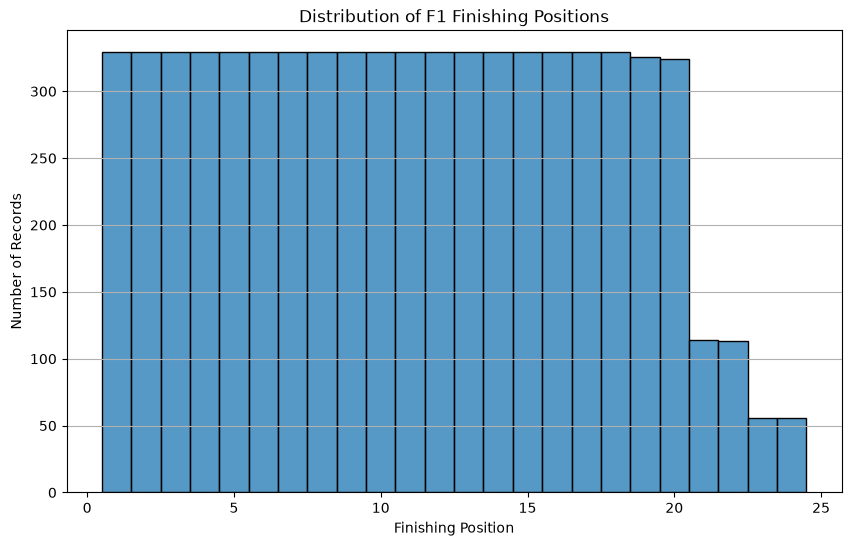

In [5]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="position",
    bins=20,
    discrete=True
)

plt.xlabel("Finishing Position")
plt.ylabel("Number of Records")
plt.title("Distribution of F1 Finishing Positions")
plt.grid(axis="y")

plt.show()

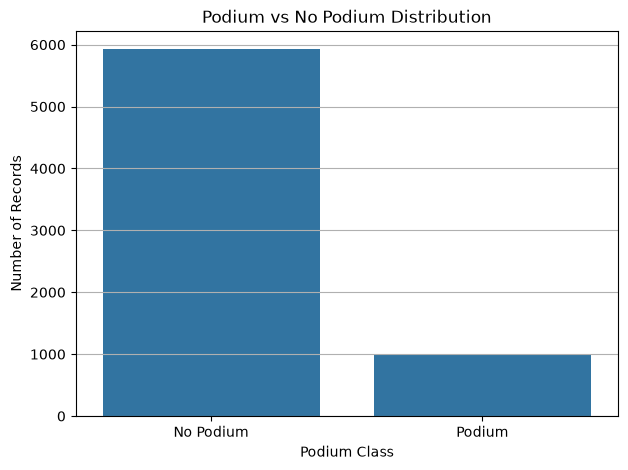


Class counts:
podium
0    5924
1     987
Name: count, dtype: int64

Class percentages:
podium
0    85.72
1    14.28
Name: proportion, dtype: float64


In [6]:
# Podium Class Distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="podium"
)

plt.xlabel("Podium Class")
plt.ylabel("Number of Records")
plt.title("Podium vs No Podium Distribution")

plt.xticks(
    [0, 1],
    ["No Podium", "Podium"]
)

plt.grid(axis="y")

plt.show()

print("\nClass counts:")
print(df["podium"].value_counts())

print("\nClass percentages:")
print(
    df["podium"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

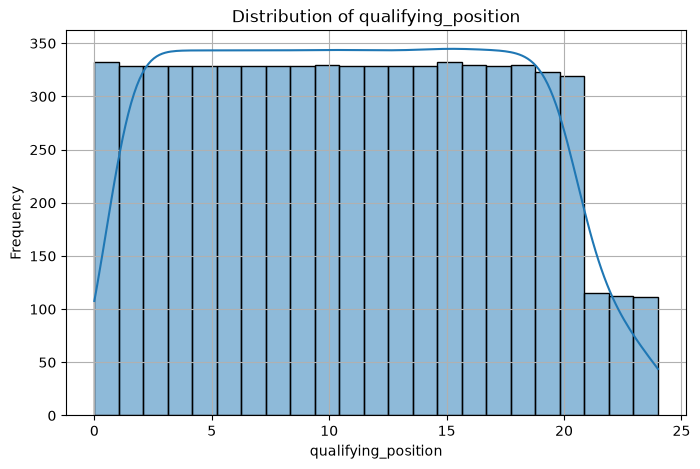

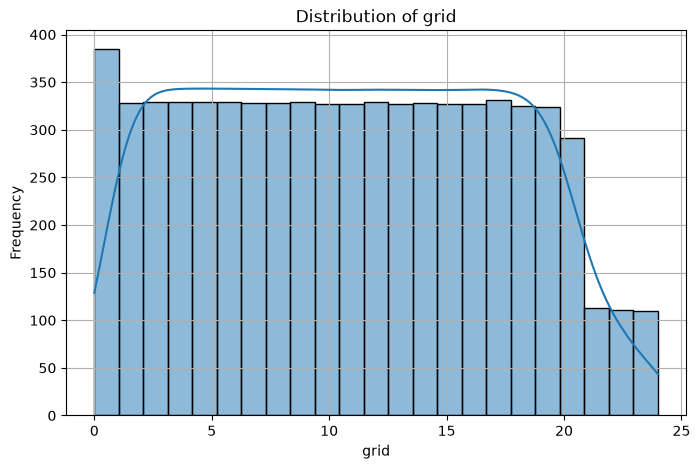

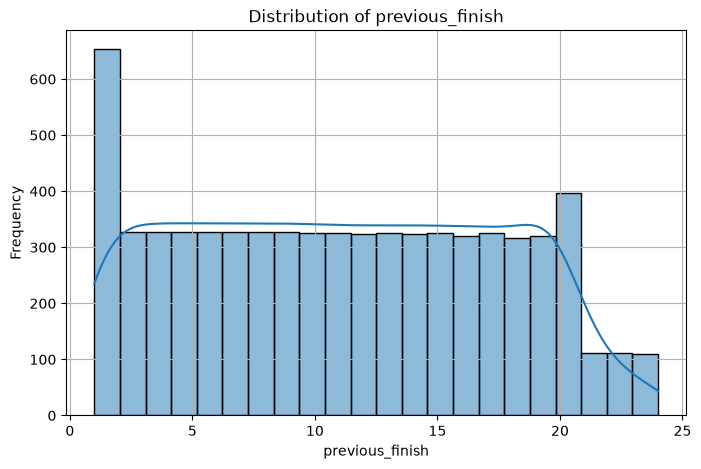

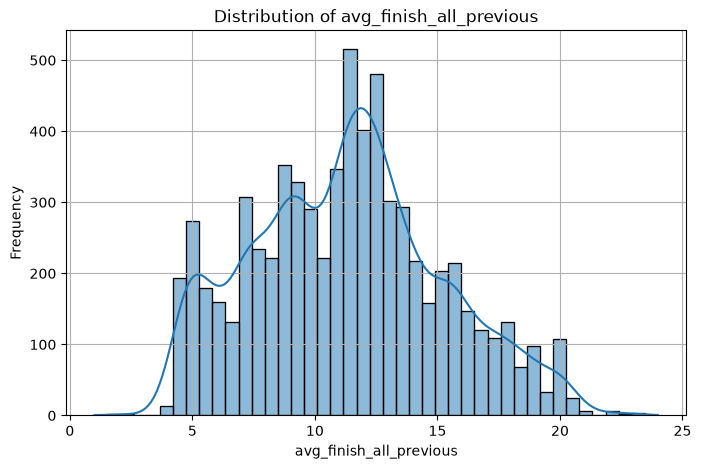

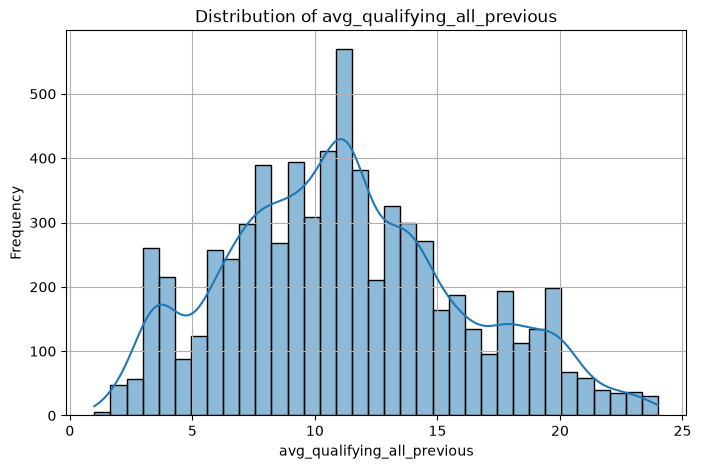

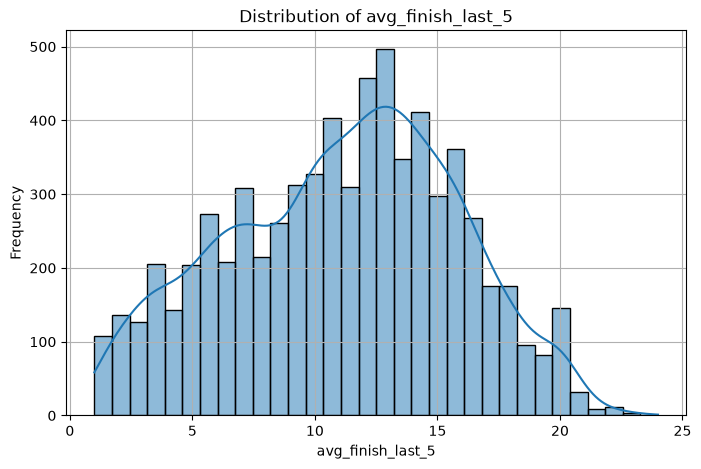

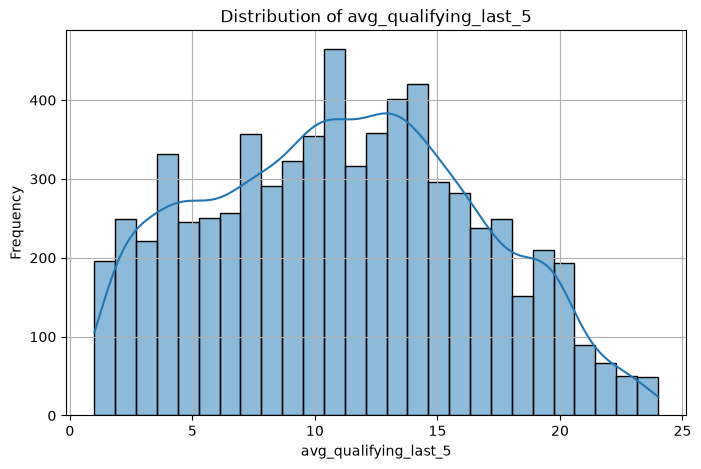

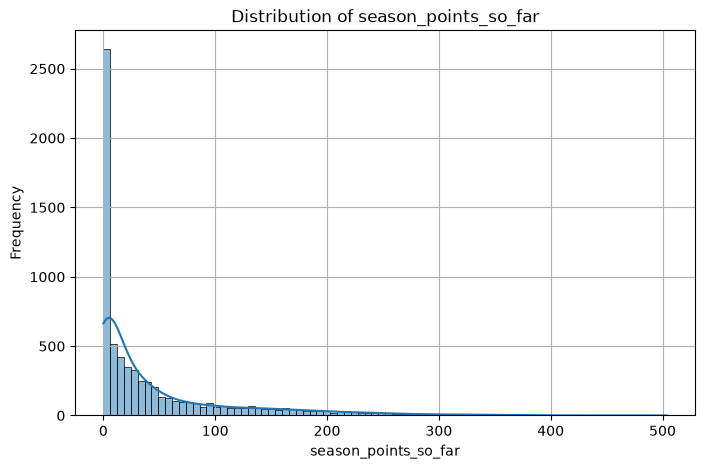

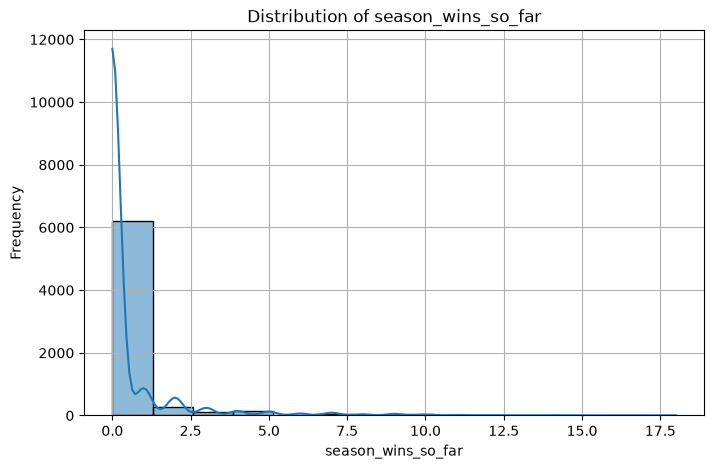

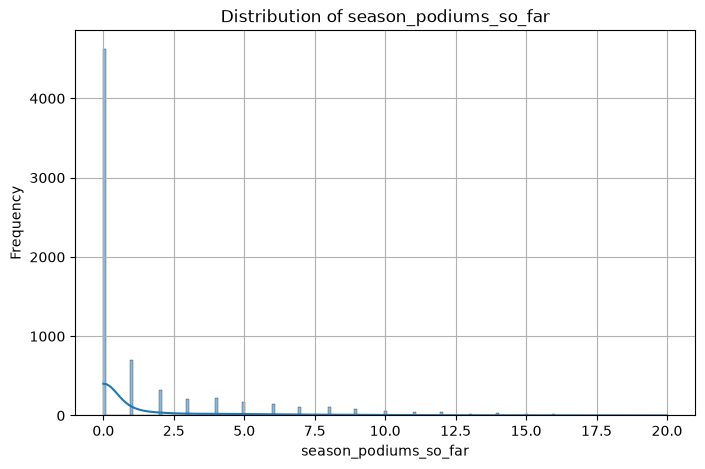

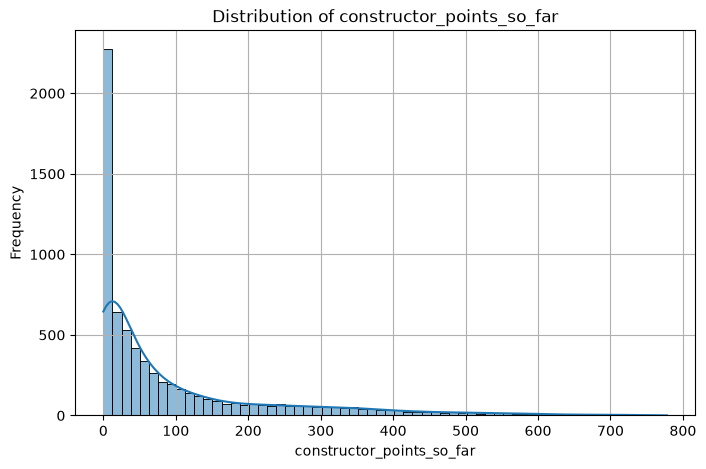

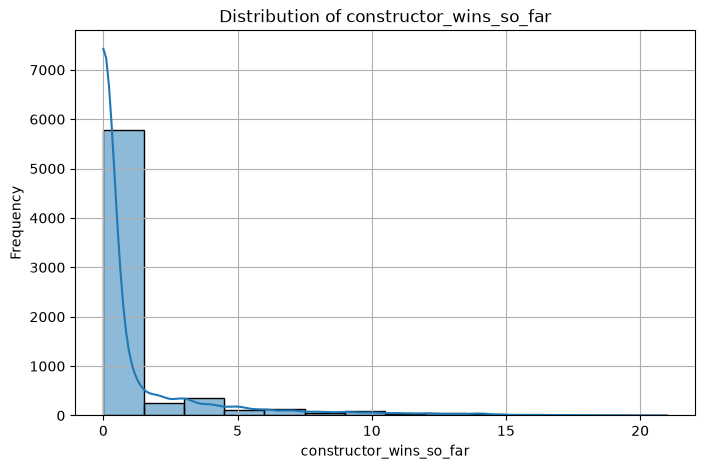

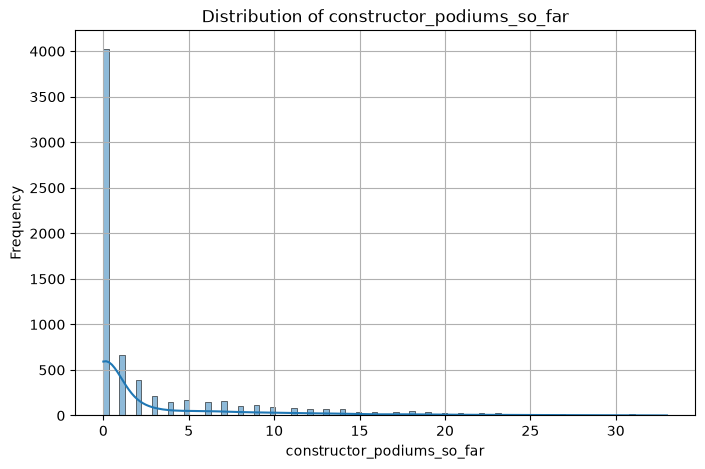

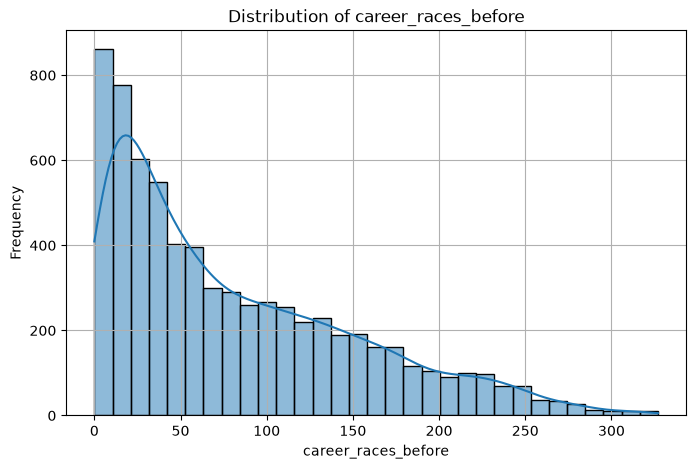

In [7]:
# Distribution of All 14 ML Features

for feature in feature_columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {feature}")
    plt.grid(True)

    plt.show()

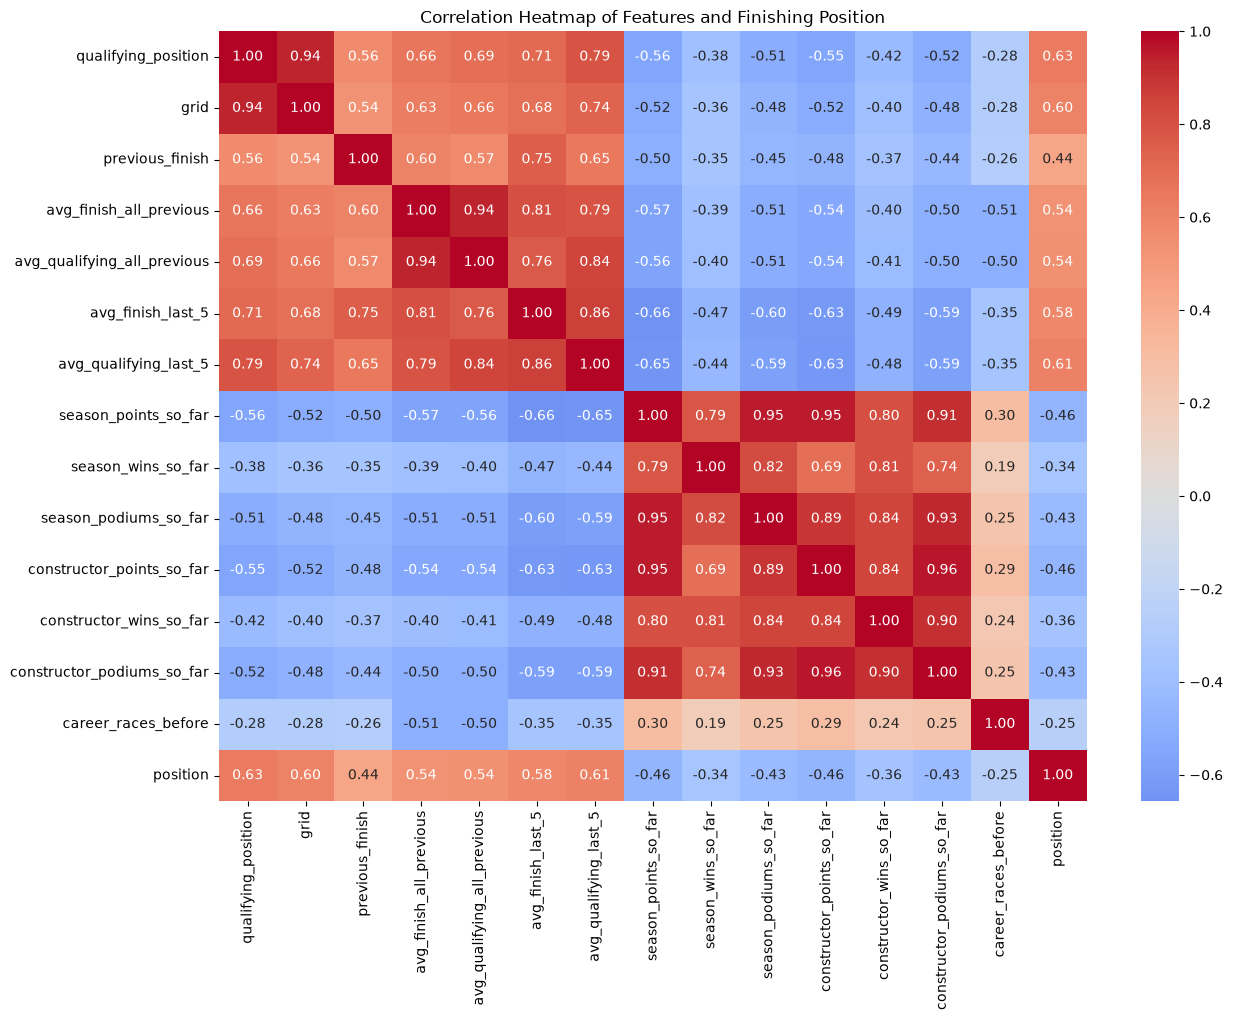

In [8]:
# Correlation Heatmap

correlation_data = df[feature_columns + ["position"]]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Features and Finishing Position")
plt.show()

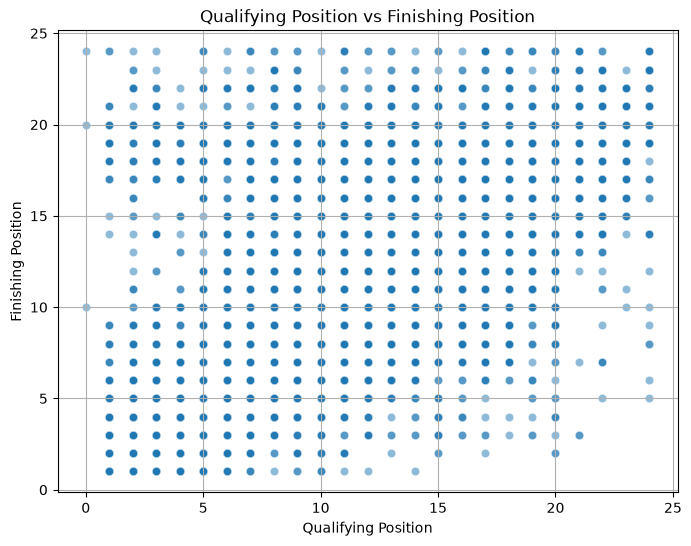

In [9]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="qualifying_position",
    y="position",
    alpha=0.5
)

plt.xlabel("Qualifying Position")
plt.ylabel("Finishing Position")
plt.title("Qualifying Position vs Finishing Position")
plt.grid(True)

plt.show()

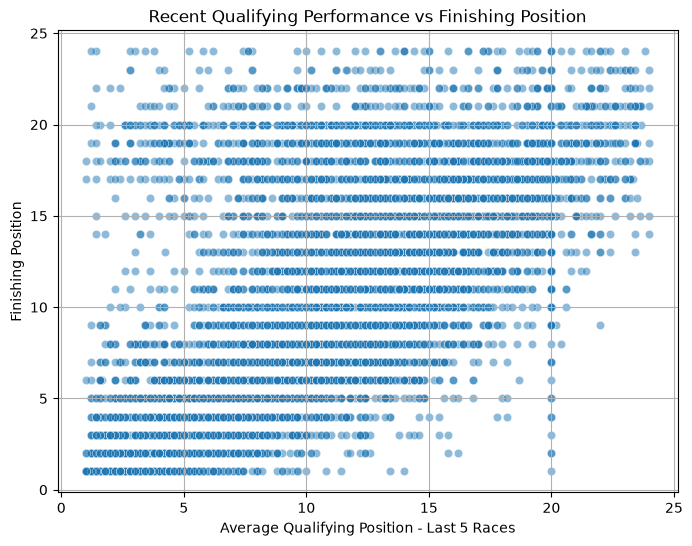

In [10]:
# Recent Qualifying Performance vs Finishing Position

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="avg_qualifying_last_5",
    y="position",
    alpha=0.5
)

plt.xlabel("Average Qualifying Position - Last 5 Races")
plt.ylabel("Finishing Position")
plt.title("Recent Qualifying Performance vs Finishing Position")
plt.grid(True)

plt.show()

In [11]:
print("""
========== EDA OBSERVATIONS ==========

1. The dataset contains 6,911 race-driver records with 35 columns.
   No duplicate rows were found.

2. Missing values are present in several raw qualifying and
   fastest-lap attributes. These attributes are not included in
   the final 14-feature modeling set.

3. Qualifying position and grid position show relatively broad
   distributions across the available race positions.

4. Historical finishing and qualifying averages are concentrated
   around the middle positions.

5. Season and constructor points, wins, and podium counts are
   right-skewed, with many observations having low accumulated
   values and fewer observations having high values.

6. The podium classification target is imbalanced, with many more
   non-podium observations than podium observations.

7. Qualifying position has a positive correlation with finishing
   position, indicating that starting from a better qualifying
   position is generally associated with a better race finish.

8. Recent qualifying performance also shows a positive relationship
   with finishing position.

9. Several engineered historical performance features are strongly
   correlated with each other, indicating some degree of redundancy
   among the features.

10. The scatter plots show that qualifying-related features have
    useful relationships with race finishing position, but there
    is still considerable variation, indicating that multiple
    factors influence race outcomes.
""")


========== EDA OBSERVATIONS ==========

1. The dataset contains 6,911 race-driver records with 35 columns.
   No duplicate rows were found.

2. Missing values are present in several raw qualifying and
   fastest-lap attributes. These attributes are not included in
   the final 14-feature modeling set.

3. Qualifying position and grid position show relatively broad
   distributions across the available race positions.

4. Historical finishing and qualifying averages are concentrated
   around the middle positions.

5. Season and constructor points, wins, and podium counts are
   right-skewed, with many observations having low accumulated
   values and fewer observations having high values.

6. The podium classification target is imbalanced, with many more
   non-podium observations than podium observations.

7. Qualifying position has a positive correlation with finishing
   position, indicating that starting from a better qualifying
   position is generally associated with a better ra